# Epic of Sun - Desafio 1
Checking the results of the model.
***

This jupyter notebook shows the results and metrics for sugarcane identification from satellite images.

It is divided in 4 parts:
* Loading libraries
* Loading data
* Loading the model
* Evaluating the model

***

## Loading libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
#import gc

#import geopandas as gpd
#import rasterio
#from rasterio.features import rasterize

import json
#import joblib
from pathlib import Path
#import os

import tensorflow as tf
#from sklearn.model_selection import train_test_split
#import segmentation_models as sm
#from tensorflow.keras import layers
#from tensorflow.keras.models import Model
from keras.models import load_model

#import keras_tuner as kt

from sklearn.metrics import (
	classification_report, 
	confusion_matrix, 
	roc_auc_score,
	roc_curve,
	precision_recall_curve, 
    precision_score,
    recall_score,
    f1_score,
	recall_score)

2026-08-31 15:50:39.591694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788202240.703580    3725 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788202241.178118    3725 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-31 15:50:44.692342: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Flags
flag_load_hyperparams = False
include_swir = False  # Set to True if you want to include SWIR bands

In [3]:
# Select the type of model you want to analyze. You can choose between "unet", "fpn", and "attention_unet".
# The code will load the corresponding model and its training history based on your selection.
flag_model = 4

if flag_model == 1:
    model_type = "unet"
    model_type_name = "U-Net"
elif flag_model == 2:
    model_type = "fpn"
    model_type_name = "FPN"
elif flag_model == 3:
    model_type = "attention_unet"
    model_type_name = "Attention U-Net"
elif flag_model == 4:
    model_type = "deeplabv3"
    model_type_name = "DeepLabV3"

In [4]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [5]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

# Specify the path to the TFRecords directory
tfrecord_path = base_path / "data" / "tfrecords"

In [6]:
patch_index = pd.read_csv(patches_path / "patch_index.csv")

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene01         0          0          0   
1  scene01         1          0         64   
2  scene01         2          0        128   
3  scene01         3          0        192   
4  scene01         4          0        256   

                                   x_patch_path  \
0  data/processed/scene01/images/patch_0000.npy   
1  data/processed/scene01/images/patch_0001.npy   
2  data/processed/scene01/images/patch_0002.npy   
3  data/processed/scene01/images/patch_0003.npy   
4  data/processed/scene01/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene01/masks/patch_0000.npy              8434  
1  data/processed/scene01/masks/patch_0001.npy             12836  
2  data/processed/scene01/masks/patch_0002.npy              9355  
3  data/processed/scene01/masks/patch_0003.npy              3983  
4  data/processed/scene01/masks/patch_0004.npy               805  
44890


## Selecting testing dataset

In [7]:
# Load the best hyperparameters from the JSON file
if flag_load_hyperparams:
	json_path = base_path / "models" / f"{model_type}" / f"{model_type}_best_hyperparams.json"

	with open(json_path, "r") as f:
		saved_params = json.load(f)
	print("Loaded hyperparameters from JSON:")
	print(saved_params)
else:
	saved_params = {
		"init_filters": 32,
		"batch_size": 64,
		"lr": 0.0001
	}
	print("Hyperparameters not loaded from JSON. Using default values:")
	print(saved_params)

Hyperparameters not loaded from JSON. Using default values:
{'init_filters': 32, 'batch_size': 64, 'lr': 0.0001}


In [8]:
# Load the count JSON file
with open(tfrecord_path / "counts.json") as f:
    counts = json.load(f)

n_train, n_val, n_test = counts["train"], counts["val"], counts["test"]

In [9]:
# Functions to create TensorFlow datasets for training, validation, and testing

def _parse_example(example_proto, include_swir=include_swir):
    feature_description = {
        "x": tf.io.FixedLenFeature([], tf.string),
        "y": tf.io.FixedLenFeature([], tf.string),
        "scene": tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    x = tf.io.parse_tensor(parsed["x"], out_type=tf.float32)
    y = tf.io.parse_tensor(parsed["y"], out_type=tf.float32)

    # Set the shape of the tensors based on whether SWIR bands are included
    if include_swir:
        x.set_shape((128, 128, 6))  # 6 bands
    else:
        x.set_shape((128, 128, 4))  # 4 bands
    y.set_shape((128, 128, 1))

    """
     If the SWIR bands are include but you only want to use the first 4 bands 
     (Blue, Green, Red, NIR), you can slice the tensor as follows:
    # 1. Always set the shape to 6 because that is how it was saved in the TFRecord
    x.set_shape((128, 128, 6))  
    y.set_shape((128, 128, 1))
    # 2. Slice the tensor if you only want to use the first 4 bands (Blue, Green, Red, NIR)
    if not include_swir:
        x = x[..., :4]  # Keeps only channels 0, 1, 2, and 3"""
    
    scene = parsed["scene"]
    return x, y, scene

def _augment(x, y, scene):
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_left_right(x); y = tf.image.flip_left_right(y)
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_up_down(x); y = tf.image.flip_up_down(y)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k); y = tf.image.rot90(y, k)
    factor = tf.random.uniform((), 0.9, 1.1)
    x = tf.clip_by_value(x * factor, 0.0, 1.0)
    return x, y, scene

def _add_indices(x, y, scene, include_swir=include_swir):
    if include_swir:
        blue, green, red, nir, swir1, swir2 = x[..., 0], x[..., 1], x[..., 2], x[..., 3], x[..., 4], x[..., 5]
    else:
        blue, green, red, nir = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    eps = 1e-8
    ndvi = (nir - red) / (nir + red + eps)
    ndwi = (green - nir) / (green + nir + eps)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)
    if include_swir:
        x = tf.stack([blue, green, red, nir, swir1, swir2, ndvi, ndwi, evi], axis=-1)
    else:
        x = tf.stack([blue, green, red, nir, ndvi, ndwi, evi], axis=-1)

    return x, y, scene

def _drop_scene(x, y, scene):
    return x, y

def make_tfrecord_dataset(prefix, batch_size, num_patches, shuffle=True,
                           augment=True, compute_indices=True, keep_scene=False, include_swir=include_swir):
    file_pattern = str(tfrecord_path / f"{prefix}_*.tfrecord")
    files = tf.data.Dataset.list_files(file_pattern, shuffle=shuffle)

    ds = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=2,       # fewer simultaneously-open files = less seeking
        block_length=16,      # read 16 records sequentially from each file before switching
        num_parallel_calls=tf.data.AUTOTUNE
    )
    # Use this one line instead of the next one to avoid the error "ValueError: 
    # num_parallel_calls must be a tf.int32 scalar tensor or None."
    ds = ds.map(lambda x: _parse_example(x, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)
    # Use this line to avoid overheading the CPU with too many parallel calls, 
    # which can lead to the error "ValueError: num_parallel_calls must be a 
    # tf.int32 scalar tensor or None."
    #ds = ds.map(_parse_example, num_parallel_calls=2)  # instead of AUTOTUNE

    if shuffle:
        ds = ds.shuffle(buffer_size=2000)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    if compute_indices:
        ds = ds.map(lambda x, y, scene: _add_indices(x, y, scene, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)

    # Drop the scene string BEFORE batching, not after -- keeps the batched
    # element structure as plain (x, y), which is what model.fit() expects.
    # Do this before .batch() rather than after, since batching a dropped
    # scalar string alongside numeric tensors is exactly what caused the
    # XLA_GPU_JIT error you hit.
    if not keep_scene:
        ds = ds.map(_drop_scene, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    num_batches = math.ceil(num_patches / batch_size)
    ds = ds.apply(tf.data.experimental.assert_cardinality(num_batches))

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [10]:
# Create TensorFlow datasets for training, validation, and testing
# This notebook is just for testing, so no train and validation datasets are created.
#train_ds = make_tfrecord_dataset("train", saved_params["batch_size"], n_train, shuffle=True, augment=True, include_swir=include_swir)
#val_ds   = make_tfrecord_dataset("val",   saved_params["batch_size"], n_val,   shuffle=False, augment=True, include_swir=include_swir)
test_ds  = make_tfrecord_dataset("test",  saved_params["batch_size"], n_test,  shuffle=False, augment=False, include_swir=include_swir)

I0000 00:00:1788202283.759910    3725 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9367 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [11]:
# Show the number of batches in training, validation, and testing sets
# Taken form the counts.json file, which is generated during the TFRecord creation process
#print("Training batches:", n_train)
#print("Validation batches:", n_val)
print("Testing batches:", n_test)

Testing batches: 8978


In [12]:
# Get a sample batch from the training generator to inspect its shape and data type
X_batch, y_batch = next(iter(test_ds))

print("Testing batch shape:", X_batch.shape)
print("Testing label shape:", y_batch.shape)
print("Testing batch data type:", X_batch.dtype)
print("Testing label data type:", y_batch.dtype)

2026-08-31 15:52:17.105477: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:370] TFRecordDataset `buffer_size` is unspecified, default to 262144


Testing batch shape: (64, 128, 128, 7)
Testing label shape: (64, 128, 128, 1)
Testing batch data type: <dtype: 'float32'>
Testing label data type: <dtype: 'float32'>


## Load the Model

In [13]:
# You can just load the model if already trained and not run again

history_dict = None  # Initialize history_dict to None

model_path = base_path / "models" / f"{model_type}" / f"{model_type}_sugarcane.keras"
history_path = base_path / "models" / f"{model_type}" / f"{model_type}_training_history.json"

if model_path.exists():
	try:
		# Pass str(model_path) to ensure compatibility
		model = load_model(str(model_path), compile=False)
		print("Successfully loaded saved model.")
	except Exception as e:
		print(f"File exists, but load_model failed with error:\n{e}")
else:
	print("File does not exist at the specified path. Check your working directory or base_path.")

if history_path.exists():
	try:
		with open(str(history_path), 'r') as f:
			history_dict = json.load(f)
		print("Successfully loaded saved training history.")
	except Exception as e:
		print(f"File exists, but loading training history failed with error:\n{e}")
else:
	print("Training history file does not exist at the specified path. Check your working directory or base_path.")

Successfully loaded saved model.
Successfully loaded saved training history.


## Evaluate the model


Visualization saved as '/home/fdesmello/Git/spacesugar2/figures/deeplabv3/deeplabv3_loss_accuracy.png'


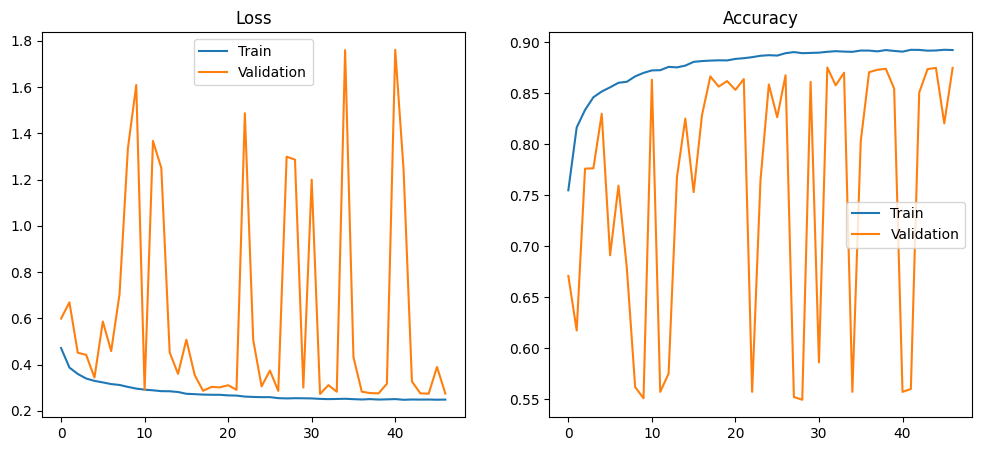

In [14]:
# Plot the learning curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train")
plt.plot(history_dict["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dict["binary_accuracy"], label="Train")
plt.plot(history_dict["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / f"{model_type}" / f"{model_type}_loss_accuracy.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()

In [15]:
# Function to stretch the RGB values for better visualization
def stretch_rgb(rgb, low=2, high=98, gamma=2.2):
    rgb = rgb.copy()

    for b in range(3):
        p_low = np.percentile(rgb[:, :, b], low)
        p_high = np.percentile(rgb[:, :, b], high)

        rgb[:, :, b] = np.clip(rgb[:, :, b], p_low, p_high)
        rgb[:, :, b] = (rgb[:, :, b] - p_low) / (p_high - p_low)

    rgb = np.power(rgb, 1 / gamma)

    return rgb

I0000 00:00:1788202381.383798  127778 service.cc:148] XLA service 0x73d77001e730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788202381.462196  127778 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-08-31 15:53:03.050199: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788202384.718617  127778 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-08-31 15:53:18.364787: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng28{k2=3,k3=0} for conv (f32[64,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,7,133,133]{3,2,1,0}, f32[64,7,7,7]{3,2,1,0}), window={size=7x7 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leak

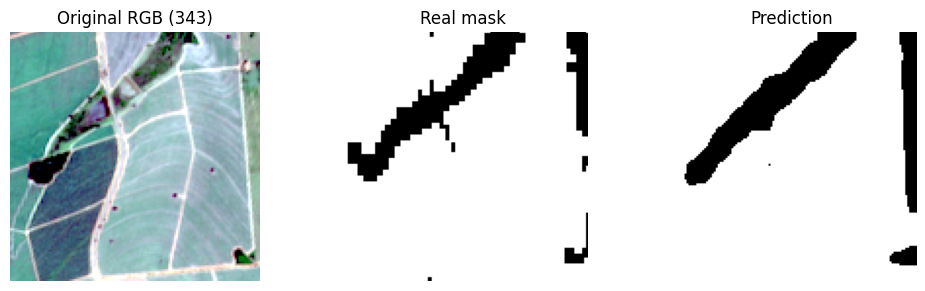

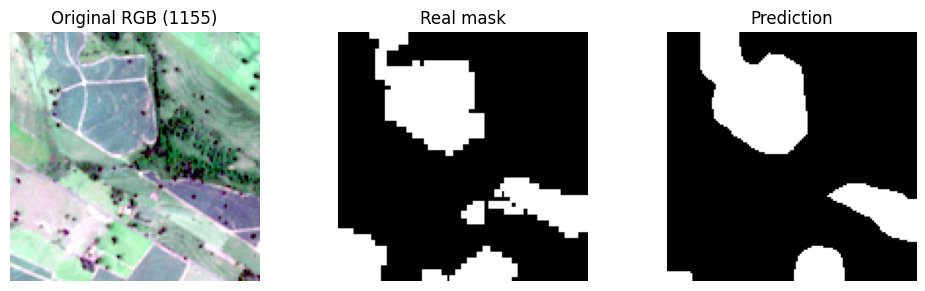

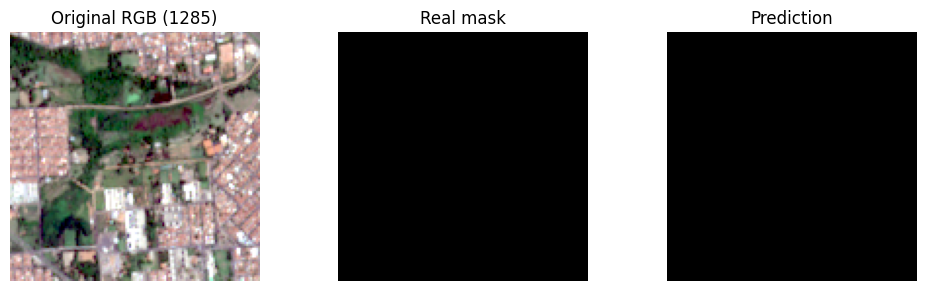

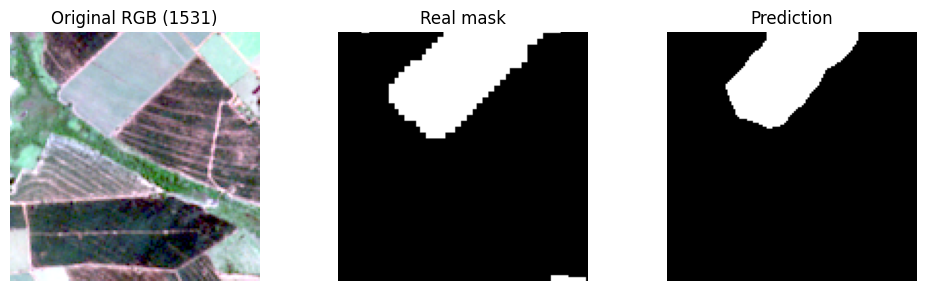

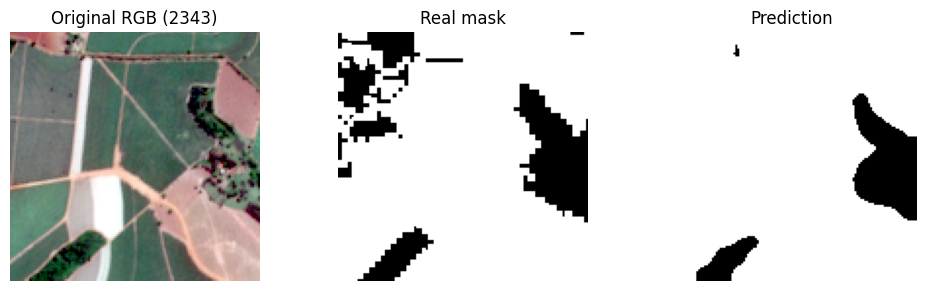

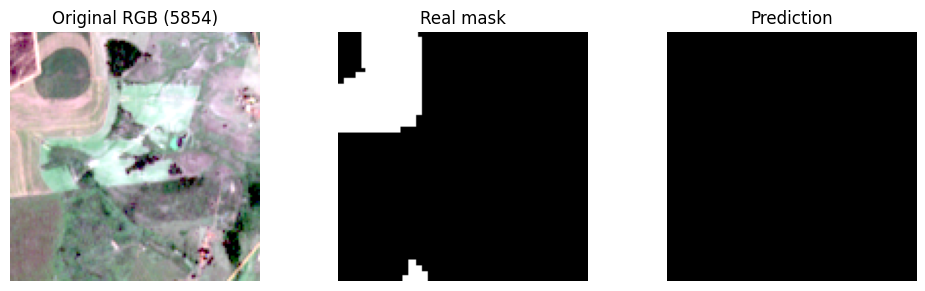

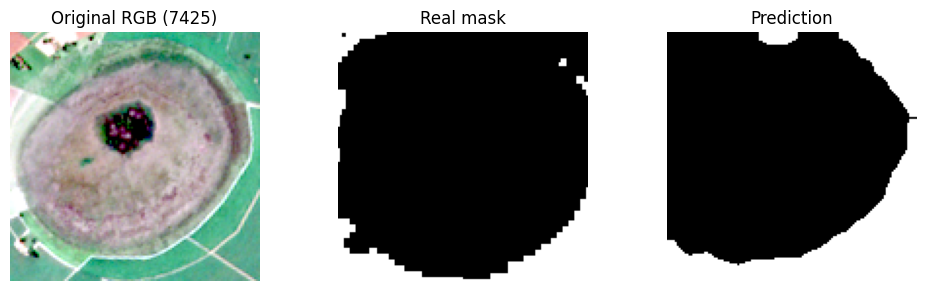

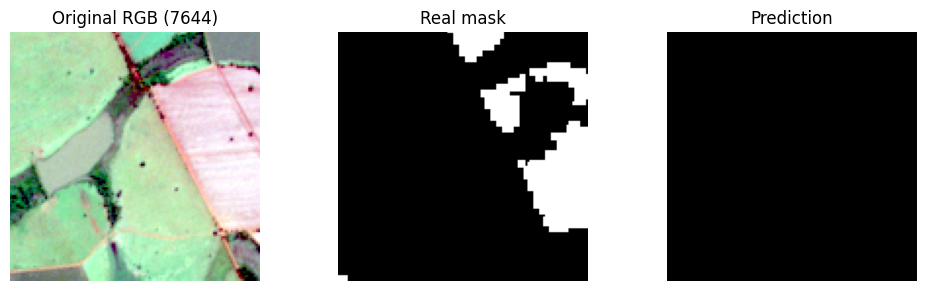

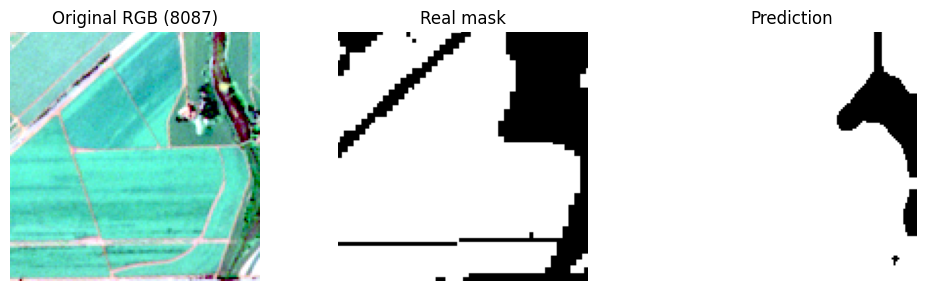

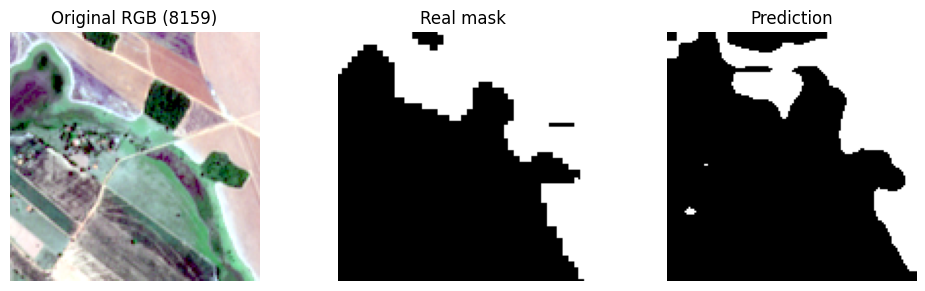

2026-08-31 15:57:01.288100: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 11.41GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-08-31 15:57:01.344961: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 11.41GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-08-31 15:57:01.345060: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 11.41GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-08-31 15:57:03.287467: E external/local_xla/xla

In [16]:
# Get the predictions and compute metrics for the test dataset

max_plots = 10
j = 0
plot_indices = set(random.sample(range(n_test), k=max_plots))
global_index = 0

# Configuration for global metrics in batches
# We will accumulate the global confusion matrix pixel by pixel: [TN, FP], [FN, TP]
global_cm = np.zeros((2, 2), dtype=np.int64)

# Statistical sampling in real-time (Simplified Reservoir Sampling)
# Collects pixels in a distributed manner for statistical graphs
sample_size = 4_000_000
collected_true = []
collected_pred = []
sampling_rate = 0.1 # Adjust this for more/less if the dataset is absurdly gigantic

for X_batch, y_batch in test_ds:
    X_batch_np = X_batch.numpy()
    y_batch_np = y_batch.numpy()
    
    # batch predictions
    #pred_batch = model(X_batch, training=False).numpy()
    pred_batch = model.predict_on_batch(X_batch)
    if hasattr(pred_batch, "numpy"):
        pred_batch = pred_batch.numpy()

    binary_pred = (pred_batch > 0.5).astype(np.uint8)
    
    # 1. Update Global Confusion Matrix (efficient and without loading everything into RAM)
    batch_true_flat = y_batch_np.ravel().astype(np.uint8)
    batch_pred_flat = binary_pred.ravel()
    
    # bincount is a very efficient way to compute the confusion matrix without loading everything into RAM
    cm_flat = np.bincount(batch_true_flat * 2 + batch_pred_flat, minlength=4)
    global_cm += cm_flat.reshape((2, 2))
    
    # 2. Collect sample for ROC/PR curves and Histogram in real-time
    # Selects a fraction of the pixels from this batch for statistical sampling
    mask_sample = np.random.rand(*batch_true_flat.shape) < sampling_rate
    #if len(collected_true) * batch_true_flat.shape[0] * sampling_rate < sample_size * 2:
    if len(collected_true) < sample_size:
        collected_true.extend(batch_true_flat[mask_sample])
        collected_pred.extend(pred_batch.ravel()[mask_sample])

    # 3. Visualization of N random images (Saves and clears memory)
    for k in range(X_batch_np.shape[0]):
        if global_index in plot_indices:
            fig, ax = plt.subplots(1, 3, figsize=(10, 3))
            rgb = np.clip(X_batch_np[k][:, :, [2, 1, 0]], 0, 1).copy()
            rgb = stretch_rgb(rgb)
            
            ax[0].imshow(rgb)
            ax[0].set_title(f"Original RGB ({global_index})")
            ax[0].axis("off")
            
            ax[1].imshow(y_batch_np[k].squeeze(), cmap="gray")
            ax[1].set_title("Real mask")
            ax[1].axis("off")
            
            ax[2].imshow(binary_pred[k].squeeze(), cmap="gray")
            ax[2].set_title("Prediction")
            ax[2].axis("off")
            
            file_path = base_path / "figures" / f"{model_type}" / f"{model_type}_sugarcane_results_{j}.png"
            plt.tight_layout()
            plt.savefig(file_path, dpi=300, bbox_inches="tight")
            
            plt.show()
            
            plt.clf()         # Clear the current figure content
            plt.close(fig)    # Close this specific figure object
            plt.close('all')  # Force-close any lingering hidden figure fragments

            j += 1
            
        global_index += 1

    # Free up memory by deleting the batch variables after processing
    del X_batch, y_batch, pred_batch

In [17]:
# Reduces the collected sample exactly to the desired size (2M points)
rng = np.random.default_rng(42)
final_indices = rng.choice(len(collected_true), size=min(sample_size, len(collected_true)), replace=False)

y_true_sample = np.array(collected_true)[final_indices]
y_pred_sample = np.array(collected_pred)[final_indices]

# Free up memory by deleting large temporary variables
del collected_true, collected_pred
print("Predictions completed and metrics accumulated successfully!")

Predictions completed and metrics accumulated successfully!


In [18]:
# Extracting metrics from the Global Confusion Matrix of millions of pixels
tn, fp, fn, tp = global_cm.ravel()

p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
final_iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0

# The ROC AUC score is calculated using the sampled true labels and predicted probabilities. 
# This approach allows for an efficient computation of the ROC AUC without requiring the entire 
# dataset to be loaded into memory, which is particularly useful for large datasets.
roc_auc = roc_auc_score(y_true_sample, y_pred_sample)

print(f"Metrics for the test dataset:")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score (Sampled): {roc_auc:.4f}")
print(f"IoU (Sugarcane Class): {final_iou:.4f}")

print("\nConfusion Matrix:")
print(global_cm)

Metrics for the test dataset:
Precision: 0.8065
Recall: 0.8165
F1-Score: 0.8115
ROC AUC Score (Sampled): 0.9111
IoU (Sugarcane Class): 0.6827

Confusion Matrix:
[[71772676 12338774]
 [11559190 51424912]]


In [ ]:
# Save data as json file for future reference
metrics_data = {
	"Model": model_type_name,
	"precision": float(p),
	"recall": float(r),
	"f1_score": float(f1),
	"roc_auc": float(roc_auc),
	"iou": float(final_iou),
	"confusion_matrix": global_cm.tolist()
}

metrics_path = base_path / "models" / f"{model_type}" / f"{model_type}_metrics_data.json"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
with open(str(metrics_path), "w") as f:
	json.dump(metrics_data, f)
print(f"Metrics data saved to '{metrics_path}'")

Metrics data saved to '/home/fdesmello/Git/spacesugar2/models/deeplabv3/deeplabv3_metrics_data.json'


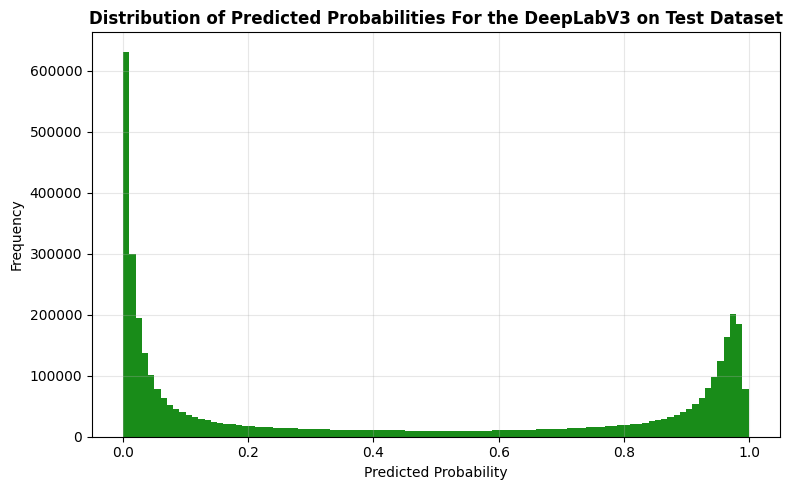

In [20]:
# 1. Gráfico Isolado de Distribuição de Probabilidades
fig1 = plt.figure(figsize=(8, 5))
ax1 = plt.subplot(1, 1, 1)
ax1.hist(y_pred_sample, bins=100, alpha=0.9, label='Sugarcane probabilities', color='green')
ax1.set_xlabel('Predicted Probability')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Distribution of Predicted Probabilities For the {model_type_name} on Test Dataset', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()

file_path_dist = base_path / "figures" / f"{model_type}" / f"{model_type}_sugarcane_probabilities.png"
plt.savefig(file_path_dist, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig1)


Final visualization panel saved as '/home/fdesmello/Git/spacesugar2/figures/deeplabv3/deeplabv3_sugarcane_results.png'


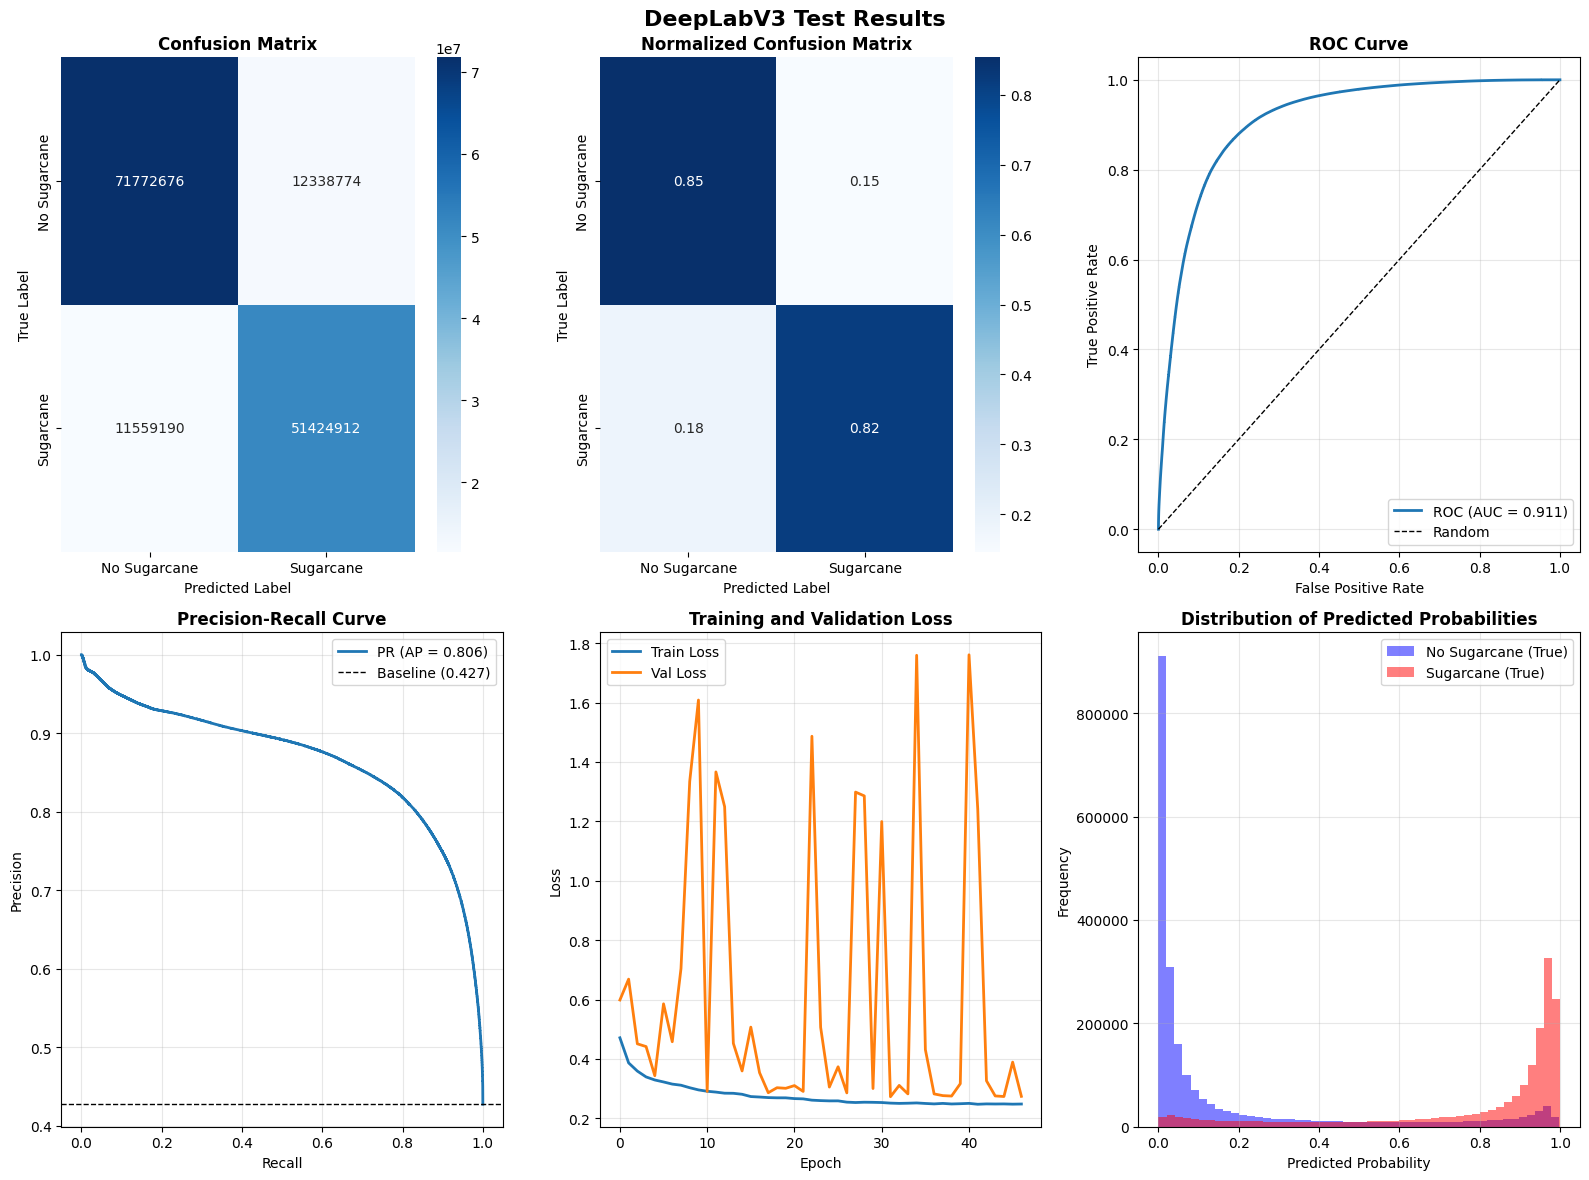

In [21]:
# --- Visualizations ---

# General panel of results for the model
fig2 = plt.figure(figsize=(16, 12))
plt.suptitle(f'{model_type_name} Test Results', fontsize=16, fontweight='bold')
class_names = ['No Sugarcane', 'Sugarcane']

# Subplot 1: Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(global_cm, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=class_names, yticklabels=class_names)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# Subplot 2: Normalized Confusion Matrix
cm_norm = pd.DataFrame(global_cm).apply(lambda x: x/sum(x), axis=1)
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues', ax=ax2, xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# Subplot 3: ROC Curve (It uses a sample of 2M)
ax3 = plt.subplot(2, 3, 3)
fpr, tpr, _ = roc_curve(y_true_sample, y_pred_sample)
ax3.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Subplot 4: Precision-Recall Curve (It uses a sample of 2M)
ax4 = plt.subplot(2, 3, 4)
precision, recall, _ = precision_recall_curve(y_true_sample, y_pred_sample)
ax4.plot(recall, precision, linewidth=2, label=f'PR (AP = {p:.3f})')
ax4.axhline(y=y_true_sample.mean(), color='k', linestyle='--', linewidth=1, label=f'Baseline ({y_true_sample.mean():.3f})')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Subplot 5: Training and Validation Loss (history_dict must be available)
if 'history_dict' in locals() or 'history_dict' in globals():
    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(history_dict["loss"], label='Train Loss', linewidth=2)
    ax5.plot(history_dict["val_loss"], label='Val Loss', linewidth=2)
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Loss')
    ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# Subplot 6: Distribution of Predicted Probabilities por Classe
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_pred_sample[y_true_sample == 0], bins=50, alpha=0.5, label='No Sugarcane (True)', color='blue')
ax6.hist(y_pred_sample[y_true_sample == 1], bins=50, alpha=0.5, label='Sugarcane (True)', color='red')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
ax6.set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
file_path_panel = base_path / "figures" / f"{model_type}" / f"{model_type}_sugarcane_results.png"
plt.savefig(file_path_panel, dpi=300, bbox_inches='tight')
print(f"\nFinal visualization panel saved as '{file_path_panel}'")
plt.show()
plt.close(fig2)